<a href="https://colab.research.google.com/github/Adhira-Deogade/pytorch-learnings/blob/main/Trash_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!git lfs install

Git LFS initialized.


In [4]:
!git clone https://huggingface.co/datasets/vatsal-a/ZotBins

Cloning into 'ZotBins'...
remote: Enumerating objects: 610, done.
remote: Total 610 (delta 0), reused 0 (delta 0), pack-reused 610 (from 1)
Receiving objects: 100% (610/610), 85.40 KiB | 9.49 MiB/s, done.
Filtering content: 100% (600/600), 9.31 MiB | 3.23 MiB/s, done.


In [5]:
import os
import pandas as pd
from torchvision.io import decode_image

In [6]:
from torch.utils.data import Dataset, DataLoader

In [37]:
all_directories = os.listdir('ZotBins')
all_classes = [directory for directory in all_directories if not directory.startswith('.')]
print(f"all_classes = {all_classes}")
classes_dict = {
    all_classes[i]: i for i in range(len(all_classes))
}
enumerated_classes = dict(enumerate(all_classes))
print(f"enumerated_classes = {enumerated_classes}")
# print(type(classes_dict))
# print(classes_dict)
for k, v in classes_dict.items():
  print(k, v)

all_classes = ['cardboard', 'glass', 'plastic', 'trash', 'metal', 'paper']
enumerated_classes = {0: 'cardboard', 1: 'glass', 2: 'plastic', 3: 'trash', 4: 'metal', 5: 'paper'}
cardboard 0
glass 1
plastic 2
trash 3
metal 4
paper 5


In [8]:
import torch
from torch.utils.data import random_split
generator1 = torch.Generator().manual_seed(42)
generator2 = torch.Generator().manual_seed(42)
print(random_split(range(10), [3, 7], generator=generator1))
# random_split(range(30), [0.3, 0.3, 0.4], generator=generator2)

[<torch.utils.data.dataset.Subset object at 0x7b72377e86d0>, <torch.utils.data.dataset.Subset object at 0x7b72377e8610>]


In [ ]:
# train_data, test_data = random_split(trash_dataset, [0.8, 0.2], generator=generator1)

In [10]:
# I am trying to create a csv file in the format
# category, image name, numerical category(using classes_dict)
# The path of the image will be created with
# Root directory(ZotBins) + class directory(cardboard) + filename
# Reverse engineering CSV file:
# I first need to create a dictionary and dump dict to csv
# I am going to try to use polars library, because it's faster
# using multiple CPU cores at once
# Learn about polars here - https://blog.jetbrains.com/pycharm/2024/07/polars-vs-pandas/
# I am creating a dictionary with three
# Maybe I can create a tuple, that would be nice
# image, numeric class
import os
import polars as pl
img_dir = 'ZotBins'
csv_filename = 'labelled_data.csv'
all_class_paths = []
all_categories = []
for class_dir in all_classes:
  numerical_category = classes_dict[class_dir]
  class_paths = os.listdir(os.path.join(img_dir, class_dir))
  numerical_cat_array = [numerical_category] * len(class_paths)
  all_class_paths.extend(class_paths)
  all_categories.extend(numerical_cat_array)
df = pl.DataFrame({"Image names": all_class_paths, "class names" :all_categories})
print(df)

df.write_csv(csv_filename, include_header=False)

shape: (600, 2)
┌──────────────────┬─────────────┐
│ Image names      ┆ class names │
│ ---              ┆ ---         │
│ str              ┆ i64         │
╞══════════════════╪═════════════╡
│ cardboard230.jpg ┆ 0           │
│ cardboard98.jpg  ┆ 0           │
│ cardboard219.jpg ┆ 0           │
│ cardboard181.jpg ┆ 0           │
│ cardboard184.jpg ┆ 0           │
│ …                ┆ …           │
│ paper520.jpg     ┆ 5           │
│ paper485.jpg     ┆ 5           │
│ paper297.jpg     ┆ 5           │
│ paper295.jpg     ┆ 5           │
│ paper446.jpg     ┆ 5           │
└──────────────────┴─────────────┘


In [55]:
class CustomTrashClassificationDatasetNumber(Dataset):
  def __init__(self, annotations_file, img_dir, classes_dict, transforms=None, target_transforms=None, train=True):
    self.img_labels = pl.read_csv(annotations_file)
    self.img_dir = img_dir
    self.classes_dict = classes_dict
    self.transforms = transforms
    self.target_transforms = target_transforms
  def __len__(self):
    return len(self.img_labels)
  def __getitem__(self, idx):
    label = self.img_labels[idx, 1]
    class_name = self.classes_dict[label]
    img_path = os.path.join(self.img_dir, class_name, self.img_labels[idx, 0])
    image = decode_image(img_path)
    if self.transforms:
      image = self.transforms(image)
    if self.target_transforms:
      label = self.target_transforms(label)
    return image, label

In [56]:
trash_dataset = CustomTrashClassificationDatasetNumber(csv_filename, img_dir, enumerated_classes)


In [57]:
print(trash_dataset)
print(trash_dataset[0])
print(len(trash_dataset))


(tensor([[[212, 213, 213,  ...,  44,  44,  46],
         [213, 214, 214,  ...,  44,  50,  54],
         [215, 215, 216,  ...,  46,  51,  50],
         ...,
         [238, 239, 239,  ..., 147, 141, 139],
         [238, 239, 239,  ..., 146, 145, 141],
         [238, 239, 238,  ..., 147, 153, 144]],

        [[182, 183, 183,  ...,  49,  48,  50],
         [183, 184, 184,  ...,  49,  55,  59],
         [185, 185, 186,  ...,  51,  56,  55],
         ...,
         [205, 206, 206,  ..., 139, 133, 131],
         [205, 206, 206,  ..., 138, 137, 133],
         [205, 206, 205,  ..., 139, 145, 136]],

        [[148, 149, 149,  ...,  45,  47,  49],
         [149, 150, 150,  ...,  45,  51,  55],
         [151, 151, 152,  ...,  45,  50,  49],
         ...,
         [174, 175, 175,  ..., 116, 110, 108],
         [174, 175, 175,  ..., 115, 114, 110],
         [174, 175, 174,  ..., 116, 122, 113]]], dtype=torch.uint8), 0)
599


In [58]:
# Split dataset into train test with torch
train_data, test_data = random_split(trash_dataset, [0.8, 0.2], generator=generator1)

In [59]:
print(len(train_data))
print(len(test_data))

480
119


In [60]:
# Create train and test dataloaders
train_dataloader = DataLoader(train_data, batch_size=16, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=16, shuffle=True)

In [63]:
import numpy as np

# Helper function to show what's in the dataset
def imshow(imgs):
    # imgs = imgs / 2 + 0.5   # unnormalize
    npimgs = imgs.numpy()
    plt.imshow(np.transpose(npimgs, (1, 2, 0)))
    plt.show()

Feature batch shape: torch.Size([16, 3, 384, 512])
Labels batch shape: torch.Size([16])


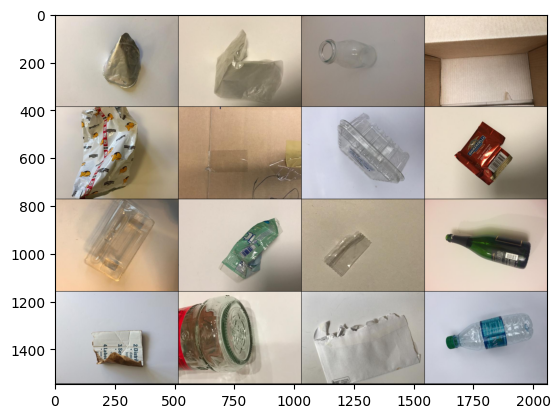

In [66]:
# Display image and label.
import matplotlib.pyplot as plt
import torchvision
import torchvision.transforms as transforms
train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")
img_grid = torchvision.utils.make_grid(train_features[0:16], nrow=4)
imshow(img_grid)
plt.show()